Nessa versão foi alterado apenas os parâmetros solver e activation do dicionário MLP_PARAMS

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [2]:
MLP_PARAMS = {
    "hidden_layer_sizes": (64, 32, 16),
    "activation": "relu",
    "solver": "adam",
    "learning_rate_init": 0.001,

    "max_iter": 1,

    "batch_size": 64,
    "alpha": 0.0001,

    "random_state": 42
}

NUM_EPOCAS = 50

THRESHOLD = 0.90

In [3]:
# ============================================================
# 2. CARREGAMENTO DO DATASET
# ============================================================

arquivo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/tabela_final/part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv"


df = pd.read_csv(arquivo)

In [4]:
# ============================================================
# 3. VARIÁVEL TARGET
# ============================================================

target = "delivered_on_time"

# ============================================================
# 4. SPLIT TEMPORAL
# ============================================================

split_date = pd.to_datetime("2018-07-01", utc=True)

date_col = pd.to_datetime(
    df["order_delivered_carrier_date"],
    utc=True
)

train_mask = date_col < split_date
test_mask = date_col >= split_date

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Treino: {len(df_train):,} linhas")
print(f"Teste: {len(df_test):,} linhas")

# ============================================================
# 5. REMOÇÃO DE COLUNAS COM POSSÍVEL DATA LEAKAGE
# ============================================================

colunas_remover = [
    target,
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "customer_city",
    "seller_city",
    "delivered_on_time", 
    "category_name",
    "review_score",
    "delivery_time_days"
]

colunas_remover = [
    coluna for coluna in colunas_remover
    if coluna in df.columns
]

Treino: 28,706 linhas
Teste: 5,114 linhas


In [5]:
# ============================================================
# 6. SEPARAÇÃO ENTRE X E Y
# ============================================================

X_train = df_train.drop(columns=colunas_remover)
y_train = df_train[target]

X_test = df_test.drop(columns=colunas_remover)
y_test = df_test[target]


# ============================================================
# 7. CONVERSÃO DE VARIÁVEIS CATEGÓRICAS
# ============================================================

X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [6]:
# ============================================================
# 8. TRATAMENTO DE VALORES AUSENTES
# ============================================================

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

X_train = X_train.fillna(
    X_train.median(numeric_only=True)
)

X_test = X_test.fillna(
    X_train.median(numeric_only=True)
)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [7]:
# ============================================================
# 9. NORMALIZAÇÃO
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Época 1/50 | Loss: 0.2108 | Validação: 0.9502
Época 2/50 | Loss: 0.1974 | Validação: 0.9502
Época 3/50 | Loss: 0.1962 | Validação: 0.9502
Época 4/50 | Loss: 0.1953 | Validação: 0.9502
Época 5/50 | Loss: 0.1945 | Validação: 0.9502
Época 6/50 | Loss: 0.1939 | Validação: 0.9502
Época 7/50 | Loss: 0.1931 | Validação: 0.9502
Época 8/50 | Loss: 0.1924 | Validação: 0.9502
Época 9/50 | Loss: 0.1917 | Validação: 0.9502
Época 10/50 | Loss: 0.1910 | Validação: 0.9516
Época 11/50 | Loss: 0.1902 | Validação: 0.9516
Época 12/50 | Loss: 0.1894 | Validação: 0.9516
Época 13/50 | Loss: 0.1885 | Validação: 0.9516
Época 14/50 | Loss: 0.1874 | Validação: 0.9516
Época 15/50 | Loss: 0.1867 | Validação: 0.9516
Época 16/50 | Loss: 0.1858 | Validação: 0.9516
Época 17/50 | Loss: 0.1850 | Validação: 0.9516
Época 18/50 | Loss: 0.1842 | Validação: 0.9516
Época 19/50 | Loss: 0.1834 | Validação: 0.9516
Época 20/50 | Loss: 0.1826 | Validação: 0.9516
Época 21/50 | Loss: 0.1818 | Validação: 0.9516
Época 22/50 | Loss: 0.

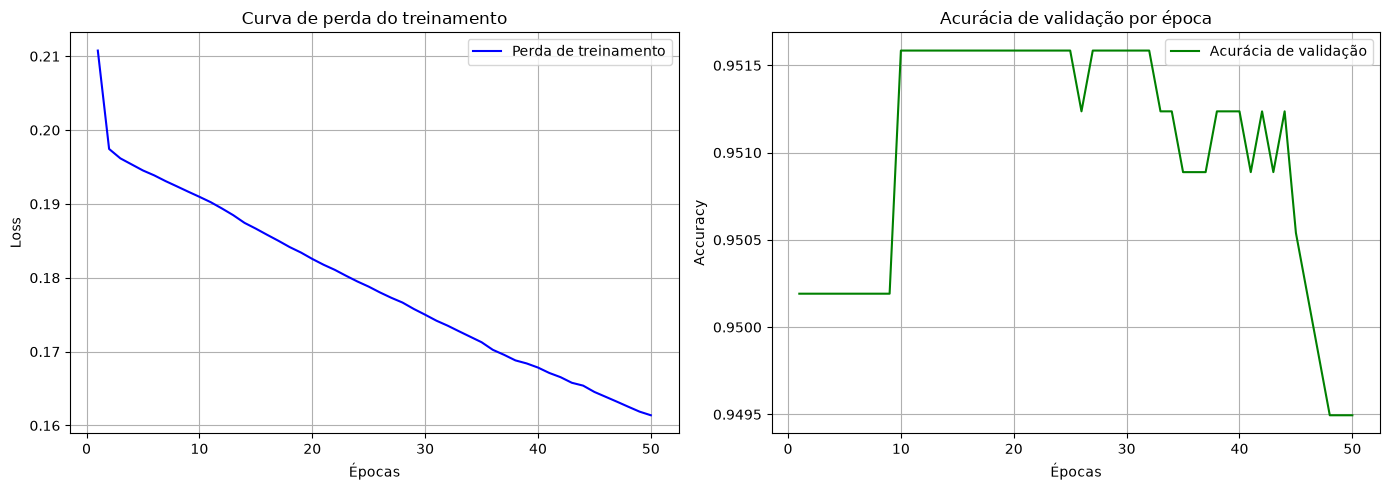


Modelo salvo em: C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl


In [8]:
# ============================================================
# 10. SEPARAÇÃO ENTRE TREINO E VALIDAÇÃO
# ============================================================

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# ============================================================
# 11. CRIAÇÃO DO MLP
# ============================================================

mlp = MLPClassifier(
    **MLP_PARAMS
)

# ============================================================
# 12. TREINAMENTO POR ÉPOCA
# ============================================================

loss_treino = []
accuracy_validacao = []

for epoca in range(NUM_EPOCAS):

    mlp.partial_fit(
        X_treino,
        y_treino,
        classes=np.array([0, 1])
    )

    loss_treino.append(
        mlp.loss_
    )

    y_validacao_pred = mlp.predict(
        X_validacao
    )

    accuracy_validacao.append(
        accuracy_score(
            y_validacao,
            y_validacao_pred
        )
    )

    print(
        f"Época {epoca + 1}/{NUM_EPOCAS} | "
        f"Loss: {mlp.loss_:.4f} | "
        f"Validação: {accuracy_validacao[-1]:.4f}"
    )

# ============================================================
# 13. GRÁFICOS DE TREINAMENTO E VALIDAÇÃO
# ============================================================

epocas = range(1, NUM_EPOCAS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 - Perda do treinamento
axes[0].plot(
    epocas,
    loss_treino,
    label="Perda de treinamento",
    color="blue"
)

axes[0].set_title("Curva de perda do treinamento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Gráfico 2 - Acurácia de validação
axes[1].plot(
    epocas,
    accuracy_validacao,
    label="Acurácia de validação",
    color="green"
)

axes[1].set_title("Acurácia de validação por época")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# SALVAMENTO DO MODELO
# ============================================================

modelo = {
    "model": mlp,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "threshold": THRESHOLD
}

caminho_modelo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl"

with open(caminho_modelo, "wb") as arquivo:
    pickle.dump(modelo, arquivo)

print(f"\nModelo salvo em: {caminho_modelo}")

# Gráfico 01
A curva de perda mostra o erro que o modelo apresenta durante o treinamento.

Curva decrescente: o modelo está aprendendo a ajustar seus pesos.

Curva estabilizada: o treinamento pode ter atingido um platô.

Curva crescente: pode indicar instabilidade ou dificuldades de otimização.

# Gráfico 02

A curva de validação mostra como o modelo classifica as amostras reservadas para validação durante o treinamento.

Acurácia crescente: o modelo está melhorando sua capacidade de classificação no conjunto de validação.

Acurácia estabilizada: pode indicar que o modelo deixou de apresentar melhorias.

Acurácia decrescente: pode indicar que o modelo está perdendo capacidade de generalização.

In [9]:
# ============================================================
# 12. PREDIÇÃO
# ============================================================

#VALORES DE PREDIÇÃO UTILIZADOS NO V1
# y_pred = mlp.predict(
#     X_test_scaled
# )

# y_prob = mlp.predict_proba(
#     X_test_scaled
# )[:, 1]

y_prob = mlp.predict_proba(
    X_test_scaled
)[:, 1]

y_pred = (y_prob >= THRESHOLD).astype(int)

In [10]:
# ============================================================
# 13. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    pos_label=0,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

In [11]:
# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS - MLP")
print("=" * 60)

print(f"Arquitetura: {MLP_PARAMS['hidden_layer_sizes']}")
print(f"Activation: {MLP_PARAMS['activation']}")
print(f"Learning rate: {MLP_PARAMS['learning_rate_init']}")
print(f"Batch size: {MLP_PARAMS['batch_size']}")
print(f"Quantidade de épocas: {NUM_EPOCAS}")

print("\nQuantidade de amostras:")
print(f"Treino: {len(X_train)}")
print(f"Teste:  {len(X_test)}")

print("\nMétricas:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

print("\nQuantidade de épocas executadas:")
print(NUM_EPOCAS)


RESULTADOS - MLP
Arquitetura: (64, 32, 16)
Activation: relu
Learning rate: 0.001
Batch size: 64
Quantidade de épocas: 50

Quantidade de amostras:
Treino: 28706
Teste:  5114

Métricas:
Accuracy:  0.8011
Precision: 0.1100
Recall:    0.0930
F1-score:  0.1008
F2-score:  0.0960
ROC-AUC:   0.5205

Matriz de confusão:
[[  57  556]
 [ 461 4040]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.11      0.09      0.10       613
           1       0.88      0.90      0.89      4501

    accuracy                           0.80      5114
   macro avg       0.49      0.50      0.49      5114
weighted avg       0.79      0.80      0.79      5114


Quantidade de épocas executadas:
50
